In [1]:
import pandas as pd
df = pd.read_excel("filtered_vs_fixed_columns.xlsx")
df.head()

,patient_id,encounter_id,code_system,code,date,value,text_value,units_of_measure,derived_by_TriNetX,source_id
0,VQm,YgN0G,LOINC,8462-4,20250504,78.0,NaN,mm[Hg],F,EHR
1,VQm,YgN0G,LOINC,8480-6,20250504,126.0,NaN,mm[Hg],F,EHR
2,VQm,YgN0G,LOINC,9279-1,20250504,24.0,NaN,{breaths}/min,F,EHR
3,VQm,YgN0G,LOINC,8310-5,20250504,98.2,NaN,[degF],F,EHR
4,VQm,YgN0G,LOINC,3141-9,20250504,162.0,NaN,[lb_av],F,EHR


In [2]:
import pandas as pd

# ensure date is datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
target_codes = ['8462-4', '8480-6', '8867-4']
df_filt = df[df['code'].isin(target_codes)].copy()

# sort so earliest date per (id, code) is first
df_filt = df_filt.sort_values(['encounter_id', 'code', 'date'])

# keep earliest row per (id, code)
earliest = df_filt.drop_duplicates(subset=['encounter_id', 'code'], keep='first')

result = earliest[['encounter_id', 'code', 'value']]
result

,encounter_id,code,value
27093,#AJot,8462-4,97.0
27105,#AJot,8480-6,144.0
27116,#AJot,8867-4,67.0
169629,#AK0gD,8462-4,56.0
169829,#AK0gD,8480-6,147.0
...,...,...,...
846607,zxzcQf,8480-6,90.0
165198,zxzdID,8462-4,56.0
165337,zxzdID,8480-6,90.0
76261,zxzuvB,8462-4,89.0


In [3]:
df_other = pd.read_csv("diagnosis_filtered.csv")
values = ["V30.4XX", "V30.5XX", "V30.6XX", "V30.7XX", "V30.9XX", "V31.4XX", "V31.5XX", "V31.6XX", "V31.7XX", "V31.9XX", "V32.4XX", "V32.5XX", "V32.6XX", "V32.7XX", "V32.9XX", "V33.4XX", "V33.5XX", "V33.6XX", "V33.7XX", "V33.9XX", "V34.4XX", "V34.5XX", "V34.6XX", "V34.7XX", "V34.9XX", "V35.4XX", "V35.5XX", "V35.6XX", "V35.7XX", "V35.9XX", "V36.4XX", "V36.5XX", "V36.6XX", "V36.7XX", "V36.9XX", "V37.4XX", "V37.5XX", "V37.6XX", "V37.7XX", "V37.9XX", "V38.4XX", "V38.5XX", "V38.6XX", "V38.7XX", "V38.9XX", "V39.40X", "V39.49X", "V39.50X", "V39.59X", "V39.60X", "V39.69X", "V39.81X", "V39.89X", "V39.9XX", "V40.4XX", "V40.5XX", "V40.6XX", "V40.7XX", "V40.9XX", "V41.4XX", "V41.5XX", "V41.6XX", "V41.7XX", "V41.9XX", "V42.4XX", "V42.5XX", "V42.6XX", "V42.7XX", "V42.9XX", "V43.41X", "V43.42X", "V43.43X", "V43.44X", "V43.51X", "V43.52X", "V43.53X", "V43.54X", "V43.61X", "V43.62X", "V43.63X", "V43.64X", "V43.71X", "V43.72X", "V43.73X", "V43.74X", "V43.91X", "V43.92X", "V43.93X", "V43.94X", "V44.4XX", "V44.5XX", "V44.6XX", "V44.7XX", "V44.9XX", "V45.4XX", "V45.5XX", "V45.6XX", "V45.7XX", "V45.9XX", "V46.4XX", "V46.5XX", "V46.6XX", "V46.7XX", "V46.9XX", "V47.4XX", "V47.5XX", "V47.51X", "V47.52X", "V47.6XX", "V47.61X", "V47.62X", "V47.7XX", "V47.9XX", "V47.91X", "V47.92X", "V48.4XX", "V48.5XX", "V48.6XX", "V48.7XX", "V48.9XX", "V49.40X", "V49.49X", "V49.50X", "V49.59X", "V49.60X", "V49.69X", "V49.81X", "V49.88X", "V49.9XX", "V50.4XX", "V50.5XX", "V50.6XX", "V50.7XX", "V50.9XX", "V51.4XX", "V51.5XX", "V51.6XX", "V51.7XX", "V51.9XX", "V52.4XX", "V52.5XX", "V52.6XX", "V52.7XX", "V52.9XX", "V53.4XX", "V53.5XX", "V53.6XX", "V53.7XX", "V53.9XX", "V54.4XX", "V54.5XX", "V54.6XX", "V54.7XX", "V54.9XX", "V55.4XX", "V55.5XX", "V55.6XX", "V55.7XX", "V55.9XX", "V56.4XX", "V56.5XX", "V56.6XX", "V56.7XX", "V56.9XX", "V57.4XX", "V57.5XX", "V57.6XX", "V57.7XX", "V57.9XX", "V58.4XX", "V58.5XX", "V58.6XX", "V58.7XX", "V58.9XX", "V59.40X", "V59.49X", "V59.50X", "V59.59X", "V59.60X", "V59.69X", "V59.81X", "V59.88X", "V59.9XX", "V60.4XX", "V60.5XX", "V60.6XX", "V60.7XX", "V60.9XX", "V61.4XX", "V61.5XX", "V61.6XX", "V61.7XX", "V61.9XX", "V62.4XX", "V62.5XX", "V62.6XX", "V62.7XX", "V62.9XX", "V63.4XX", "V63.5XX", "V63.6XX", "V63.7XX", "V63.9XX", "V64.4XX", "V64.5XX", "V64.6XX", "V64.7XX", "V64.9XX", "V65.4XX", "V65.5XX", "V65.6XX", "V65.7XX", "V65.9XX", "V66.4XX", "V66.5XX", "V66.6XX", "V66.7XX", "V66.9XX", "V67.4XX", "V67.5XX", "V67.6XX", "V67.7XX", "V67.9XX", "V68.4XX", "V68.5XX", "V68.6XX", "V68.7XX", "V68.9XX", "V69.40X", "V69.49X", "V69.50X", "V69.59X", "V69.60X", "V69.69X", "V69.81X", "V69.88X", "V69.9XX", "V70.4XX", "V70.5XX", "V70.6XX", "V70.7XX", "V70.9XX", "V71.4XX", "V71.5XX", "V71.6XX", "V71.7XX", "V71.9XX", "V72.4XX", "V72.5XX", "V72.6XX", "V72.7XX", "V72.9XX", "V73.4XX", "V73.5XX", "V73.6XX", "V73.7XX", "V73.9XX", "V74.4XX", "V74.5XX", "V74.6XX", "V74.7XX", "V74.9XX", "V75.4XX", "V75.5XX", "V75.6XX", "V75.7XX", "V75.9XX", "V76.4XX", "V76.5XX", "V76.6XX", "V76.7XX", "V76.9XX", "V77.4XX", "V77.5XX", "V77.6XX", "V77.7XX", "V77.9XX", "V78.4XX", "V78.5XX", "V78.6XX", "V78.7XX", "V78.9XX", "V79.40X", "V79.49X", "V79.50X", "V79.59X", "V79.60X", "V79.69X", "V79.81X", "V79.88X", "V79.9XX", "V83.0XX", "V83.1XX", "V83.2XX", "V83.3XX", "V84.0XX", "V84.1XX", "V84.2XX", "V84.3XX", "V85.0XX", "V85.1XX", "V85.2XX", "V85.3XX", "V86.01X", "V86.02X", "V86.03X", "V86.04X", "V86.05X", "V86.06X", "V86.09X", "V86.11X", "V86.12X", "V86.13X", "V86.14X", "V86.15X", "V86.16X", "V86.19X", "V86.21X", "V86.22X", "V86.23X", "V86.24X", "V86.25X", "V86.26X", "V86.29X", "V86.31X", "V86.32X", "V86.33X", "V86.34X", "V86.35X", "V86.36X", "V86.39X", "V87.0XX", "V87.1XX", "V87.2XX", "V87.3XX", "V87.4XX", "V87.5XX", "V87.6XX", "V87.7XX", "V87.8XX", "V89.2XX", "V20.3XX", "V20.09X", "V20.4XX", "V20.19X", "V20.5XX", "V20.29X", "V20.9XX", "V20.39X", "V21.3XX", "V20.49X", "V21.4XX", "V20.59X", "V21.5XX", "V20.99X", "V21.9XX", "V21.09X", "V22.3XX", "V21.19X", "V22.4XX", "V21.29X", "V22.5XX", "V21.39X", "V22.9XX", "V21.49X", "V23.3XX", "V21.59X", "V23.4XX", "V21.99X", "V23.5XX", "V22.51X", "V22.59X", "V23.9XX", "V22.09X", "V24.3XX", "V22.19X", "V24.4XX", "V22.29X", "V24.5XX", "V22.31X", "V22.39X", "V24.9XX", "V22.41X", "V22.49X", "V25.3XX", "V22.91X", "V22.99X", "V25.4XX", "V23.09X", "V25.5XX", "V23.19X", "V25.9XX", "V23.29X", "V26.3XX", "V23.31X", "V23.39X", "V26.4XX", "V23.41X", "V23.49X", "V26.5XX", "V23.51X", "V23.59X", "V26.9XX", "V23.91X", "V23.99X", "V27.3XX", "V24.09X", "V27.4XX", "V24.19X", "V27.5XX", "V24.29X", "V27.9XX", "V24.31X", "V24.39X", "V28.3XX", "V24.41X", "V24.49X", "V28.4XX", "V24.51X", "V24.59X", "V28.5XX", "V24.91X", "V24.99X", "V28.9XX", "V25.09X", "V29.40X", "V25.19X", "V29.49X", "V25.29X", "V29.50X", "V25.39X", "V29.59X", "V25.49X", "V29.60X", "V25.59X", "V29.69X", "V25.99X", "V29.81X", "V26.09X", "V29.88X", "V26.19X", "V29.9XX", "V26.29X", "V12.3XX", "V12.4XX", "V12.5XX", "V12.9XX", "V13.3XX", "V13.4XX", "V13.5XX", "V13.9XX", "V14.3XX", "V14.4XX", "V14.5XX", "V14.9XX", "V19.40X", "V19.49X", "V19.50X", "V19.59X", "V19.60X", "V19.69X", "V19.9XX", "V02.10X", "V02.11X", "V02.12X", "V02.131", "V02.138", "V02.19X", "V02.90X", "V02.91X", "V02.92X", "V02.931", "V02.938", "V02.99X", "V03.10X", "V03.11X", "V03.12X", "V03.131", "V03.138", "V03.19X", "V03.90X", "V03.91X", "V03.92X", "V03.931", "V03.938", "V03.99X", "V04.10X", "V04.11X", "V04.12X", "V04.131", "V04.138", "V04.19X", "V04.90X", "V04.91X", "V04.92X", "V04.931", "V04.938", "V04.99X", "V09.20X", "V09.21X", "V09.29X", "V09.3XX", "V80.31X", "V80.32X", "V80.41X", "V80.42X", "V80.51X", "V80.52X", "V81.1XX", "V82.1XX", "V20.0XX", "V26.39X", "V20.1XX", "V26.49X", "V20.2XX", "V26.59X", "V21.0XX", "V26.99X", "V21.1XX", "V27.09X", "V21.2XX", "V27.19X", "V22.0XX", "V27.29X", "V22.1XX", "V27.39X", "V22.2XX", "V27.49X", "V23.0XX", "V27.59X", "V23.1XX", "V27.99X", "V23.2XX", "V28.09X", "V24.0XX", "V28.19X", "V24.1XX", "V28.29X", "V24.2XX", "V28.39X", "V25.0XX", "V28.49X", "V25.1XX", "V28.59X", "V25.2XX", "V28.99X", "V26.0XX", "V29.008", "V26.1XX", "V29.098", "V26.2XX", "V29.108", "V27.0XX", "V29.198", "V27.1XX", "V29.208", "V27.2XX", "V29.298", "V28.0XX", "V29.39X", "V28.1XX", "V29.401", "V29.408", "V28.2XX", "V29.491", "V29.498", "V29.00X", "V29.501", "V29.508", "V29.09X", "V29.591", "V29.598", "V29.10X", "V29.601", "V29.608", "V29.19X", "V29.691", "V29.698", "V29.20X", "V29.818", "V29.29X", "V29.888", "V29.3XX", "V29.91X", "V29.99X", "V30.0XX", "V30.1XX", "V30.2XX", "V30.3XX", "V31.0XX", "V31.1XX", "V31.2XX", "V31.3XX", "V32.0XX", "V32.1XX", "V32.2XX", "V32.3XX", "V33.0XX", "V33.1XX", "V33.2XX", "V33.3XX", "V34.0XX", "V34.1XX", "V34.2XX", "V34.3XX", "V35.0XX", "V35.1XX", "V35.2XX", "V35.3XX", "V36.0XX", "V36.1XX", "V36.2XX", "V36.3XX", "V37.0XX", "V37.1XX", "V37.2XX", "V37.3XX", "V38.0XX", "V38.1XX", "V38.2XX", "V38.3XX", "V39.00X", "V39.09X", "V39.10X", "V39.19X", "V39.20X", "V39.29X", "V39.3XX", "V40.0XX", "V40.1XX", "V40.2XX", "V40.3XX", "V41.0XX", "V41.1XX", "V41.2XX", "V41.3XX", "V42.0XX", "V42.1XX", "V42.2XX", "V42.3XX", "V43.01X", "V43.02X", "V43.03X", "V43.04X", "V43.11X", "V43.12X", "V43.13X", "V43.14X", "V43.21X", "V43.22X", "V43.23X", "V43.24X", "V43.31X", "V43.32X", "V43.33X", "V43.34X", "V44.0XX", "V44.1XX", "V44.2XX", "V44.3XX", "V45.0XX", "V45.1XX", "V45.2XX", "V45.3XX", "V46.0XX", "V46.1XX", "V46.2XX", "V46.3XX", "V47.0XX", "V47.01X", "V47.02X", "V47.1XX", "V47.11X", "V47.12X", "V47.2XX", "V47.3XX", "V47.31X", "V47.32X", "V48.0XX", "V48.1XX", "V48.2XX", "V48.3XX", "V49.00X", "V49.09X", "V49.10X", "V49.19X", "V49.20X", "V49.29X", "V49.3XX", "V50.0XX", "V50.1XX", "V50.2XX", "V50.3XX", "V51.0XX", "V51.1XX", "V51.2XX", "V51.3XX", "V52.0XX", "V52.1XX", "V52.2XX", "V52.3XX", "V53.0XX", "V53.1XX", "V53.2XX", "V53.3XX", "V54.0XX", "V54.1XX", "V54.2XX", "V54.3XX", "V55.0XX", "V55.1XX", "V55.2XX", "V55.3XX", "V56.0XX", "V56.1XX", "V56.2XX", "V56.3XX", "V57.0XX", "V57.1XX", "V57.2XX", "V57.3XX", "V58.0XX", "V58.1XX", "V58.2XX", "V58.3XX", "V59.00X", "V59.09X", "V59.10X", "V59.19X", "V59.20X", "V59.29X", "V59.3XX", "V60.0XX", "V60.1XX", "V60.2XX", "V60.3XX", "V61.0XX", "V61.1XX", "V61.2XX", "V61.3XX", "V62.0XX", "V62.1XX", "V62.2XX", "V62.3XX", "V63.0XX", "V63.1XX", "V63.2XX", "V63.3XX", "V64.0XX", "V64.1XX", "V64.2XX", "V64.3XX", "V65.0XX", "V65.1XX", "V65.2XX", "V65.3XX", "V66.0XX", "V66.1XX", "V66.2XX", "V66.3XX", "V67.0XX", "V67.1XX", "V67.2XX", "V67.3XX", "V68.0XX", "V68.1XX", "V68.2XX", "V68.3XX", "V69.00X", "V69.09X", "V69.10X", "V69.19X", "V69.20X", "V69.29X", "V69.3XX", "V70.0XX", "V70.1XX", "V70.2XX", "V70.3XX", "V71.0XX", "V71.1XX", "V71.2XX", "V71.3XX", "V72.0XX", "V72.1XX", "V72.2XX", "V72.3XX", "V73.0XX", "V73.1XX", "V73.2XX", "V73.3XX", "V74.0XX", "V74.1XX", "V74.2XX", "V74.3XX", "V75.0XX", "V75.1XX", "V75.2XX", "V75.3XX", "V76.0XX", "V76.1XX", "V76.2XX", "V76.3XX", "V77.0XX", "V77.1XX", "V77.2XX", "V77.3XX", "V78.0XX", "V78.1XX", "V78.2XX", "V78.3XX", "V79.00X", "V79.09X", "V79.10X", "V79.19X", "V79.20X", "V79.29X", "V79.3XX", "V81.0XX", "V82.0XX", "V84.5XX", "V84.6XX", "V84.7XX", "V84.9XX", "V85.5XX", "V85.6XX", "V85.7XX", "V85.9XX", "V86.51X", "V86.54X", "V86.55X", "V86.56X", "V86.61X", "V86.64X", "V86.65X", "V86.66X", "V86.71X", "V86.74X", "V86.75X", "V86.76X", "V86.91X", "V86.94X", "V86.95X", "V86.96X", "V88.0XX", "V88.1XX", "V88.2XX", "V88.3XX", "V88.4XX", "V88.5XX", "V88.6XX", "V88.7XX", "V88.8XX", "V89.0XX", "V00.111", "V00.121", "V00.131", "V00.141", "V00.151", "V00.181", "V00.211", "V00.221", "V00.281", "V00.311", "V00.321", "V00.381", "V00.811", "V00.821", "V00.831", "V00.841", "V00.891", "W00.0XX", "W00.1XX", "W00.2XX", "W00.9XX", "W01.0XX", "W01.10X", "W01.110", "W01.111", "W01.118", "W01.119", "W01.190", "W01.198", "W03.XXX", "W04.XXX", "W05.0XX", "W05.1XX", "W05.2XX", "W06.XXX", "W07.XXX", "W08.XXX", "W09.0XX", "W09.1XX", "W09.2XX", "W09.8XX", "W10.0XX", "W10.1XX", "W10.2XX", "W10.8XX", "W10.9XX", "W11.XXX", "W12.XXX", "W13.0XX", "W13.1XX", "W13.2XX", "W13.3XX", "W13.4XX", "W13.8XX", "W13.9XX", "W14.XXX", "W15.XXX", "W16.012", "W16.022", "W16.032", "W16.112", "W16.122", "W16.132", "W16.212", "W16.222", "W16.312", "W16.322", "W16.332", "W16.42X", "W16.512", "W16.522", "W16.532", "W16.612", "W16.622", "W16.712", "W16.722", "W16.812", "W16.822", "W16.832", "W16.92X", "W17.0XX", "W17.1XX", "W17.2XX", "W17.3XX", "W17.4XX", "W17.81X", "W17.82X", "W17.89X", "W18.11X", "W18.12X", "W18.2XX", "W18.30X", "W18.31X", "W18.39X", "W19.XXX"]
unique_first3 = list({str(x)[:3] for x in values})
df_other = df_other[df_other["code_system"] == "ICD-10-CM"]

df_other = df_other[df_other["code"].str[:3].isin(unique_first3)]
df_other.head()
wide = (
    result
    .pivot(index='encounter_id', columns='code', values='value')
    .reset_index()
)
df_merged = df_other.merge(wide, on='encounter_id', how='left')
df_merged_clean = df_merged.dropna(
    subset=['8462-4', '8480-6', '8867-4'],
    how='any'
)
df_merged_clean['shock_index'] = (
    df_merged_clean['8867-4'] / df_merged_clean['8480-6']
)

df_merged_clean


,patient_id,encounter_id,code_system,code,principal_diagnosis_indicator,admitting_diagnosis,reason_for_visit,date,derived_by_TriNetX,source_id,8462-4,8480-6,8867-4,shock_index
2,ThBJ,WB68H,ICD-10-CM,W18.39,S,U,U,20211208,F,EHR,88.0,129.0,66.0,0.511628
3,ThBJ,WB68H,ICD-10-CM,W18.39,S,U,U,20220217,F,EHR,88.0,129.0,66.0,0.511628
16,yA2P,1gdIHC,ICD-10-CM,W19.XXXA,Unknown,U,U,20240704,F,EHR,76.0,117.0,96.0,0.820513
17,Lwi3E,OgTrB,ICD-10-CM,W18.39XA,Unknown,U,U,20230312,F,EHR,75.0,176.0,65.0,0.369318
18,Lwi3E,OgTrB,ICD-10-CM,W18.39XA,Unknown,U,U,20230312,F,EHR,75.0,176.0,65.0,0.369318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3913,vAB3J,ywq42R,ICD-10-CM,W01.198A,Unknown,U,U,20210606,F,EHR,85.0,159.0,74.0,0.465409
3914,vAB3J,ygr42R,ICD-10-CM,W01.198A,Unknown,U,U,20210606,F,EHR,88.0,150.0,74.0,0.493333
3976,GwW2H,JQYI7m,ICD-10-CM,W19.XXXA,Unknown,U,U,20230905,F,EHR,70.0,122.0,88.0,0.721311
3977,GwW2H,JQYI7m,ICD-10-CM,W19.XXXA,Unknown,U,U,20230905,F,EHR,70.0,122.0,88.0,0.721311


/var/folders/6t/5kq9jshx5kd7bz14tcgvxrkw0000gn/T/ipykernel_15690/1323062662.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


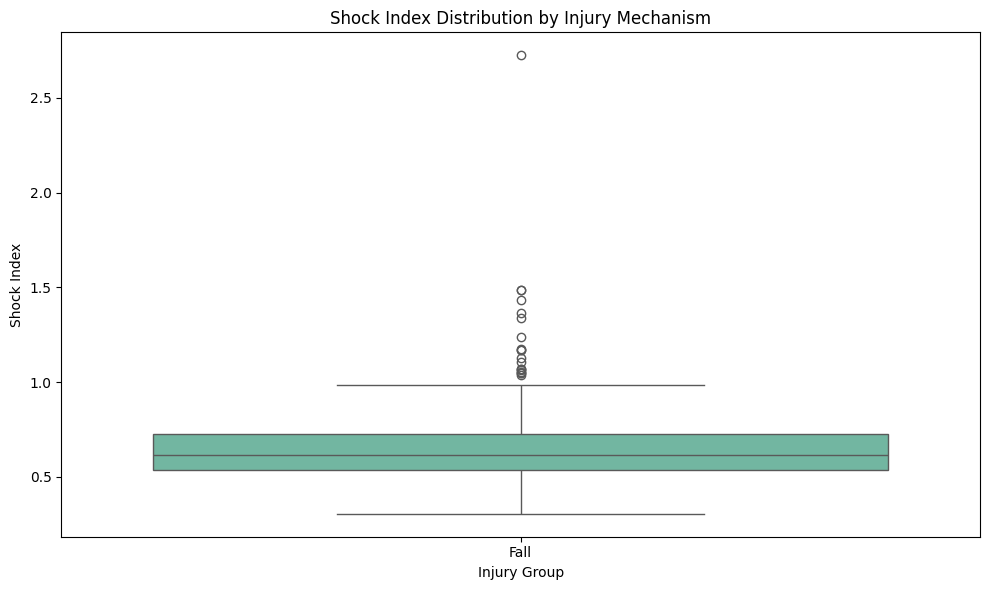

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# clean ICD column
df_merged_clean['code'] = (
    df_merged_clean['code']
    .astype(str)
    .str.strip()
    .str.upper()
)

# classify injury mechanism
def classify_icd(code):
    if pd.isna(code):
        return np.nan
    if code.startswith("V"):
        return "Motor Vehicle Accident"
    if code.startswith("W"):
        return "Fall"
    return "Other"

df_merged_clean['injury_group'] = df_merged_clean['code'].apply(classify_icd)
df_plot = df_merged_clean[
    df_merged_clean['injury_group'].isin(["Motor Vehicle Accident", "Fall"])
].copy()
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot,
    x='injury_group',
    y='shock_index',
    palette='Set2'
)

plt.title("Shock Index Distribution by Injury Mechanism")
plt.xlabel("Injury Group")
plt.ylabel("Shock Index")
plt.tight_layout()
plt.show()



['patient_id', 'encounter_id', 'code_system', 'code', 'principal_diagnosis_indicator', 'admitting_diagnosis', 'reason_for_visit', 'date', 'derived_by_TriNetX', 'source_id', '8462-4', '8480-6', '8867-4', 'shock_index', 'injury_group', 'earliest_date']
['patient_id_x', 'encounter_id', 'code_system', 'code', 'principal_diagnosis_indicator', 'admitting_diagnosis', 'reason_for_visit', 'date', 'derived_by_TriNetX', 'source_id', '8462-4', '8480-6', '8867-4', 'shock_index', 'injury_group', 'earliest_date', 'patient_id_y']


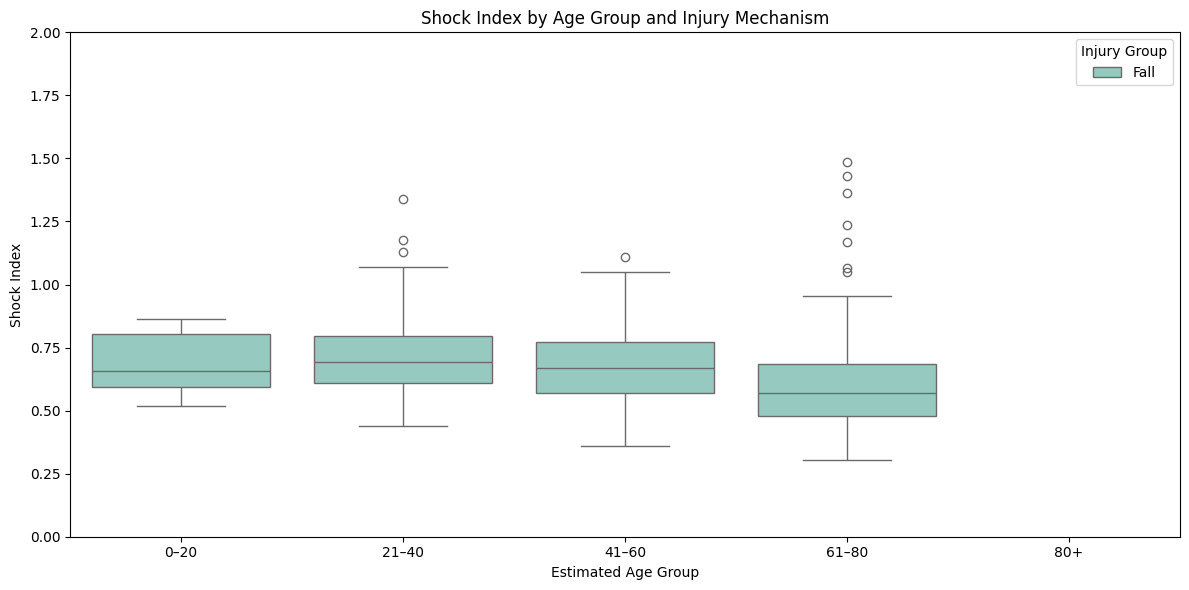

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# -----------------------------
# 1. EARLIEST DATE PER ENCOUNTER
# -----------------------------
# ensure date is datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')

# get earliest date per encounter_id
earliest_date_df = (
    df.groupby('encounter_id', as_index=False)['date']
      .min()
      .rename(columns={'date': 'earliest_date'})
)

# merge back
df_final = df_merged_clean.merge(earliest_date_df, on='encounter_id', how='left')

df_final = (
    df_final
    .rename(columns={'patient_id_x': 'patient_id'})
    .drop(columns=['patient_id_y'], errors='ignore')
)
print(df_final.columns.tolist())
# 2. merge patient_id from df_other
df_other_unique = (
    df_other.sort_values('encounter_id')
            .drop_duplicates(subset='encounter_id', keep='first')
            [['encounter_id', 'patient_id']]
)

df_final = df_final.merge(df_other_unique, on='encounter_id', how='left')
print(df_final.columns.tolist())
df_final = df_final.rename(columns={'patient_id_y': 'patient_id'})
df_final = df_final.drop(columns=['patient_id_x'], errors='ignore')
df_final['patient_id'] = df_final['patient_id'].astype(str).str.strip()

# 3. NOW patient_id exists → clean it
df_final['patient_id'] = df_final['patient_id'].astype(str).str.strip()

# -----------------------------
# 3. MERGE birth year FROM df_birth
# -----------------------------
df_birth = pd.read_csv("patient_filtered.csv")
# 4. clean df_birth
df_birth['patient_id'] = df_birth['patient_id'].astype(str).str.strip()

# 5. merge birth year
df_final = df_final.merge(
    df_birth[['patient_id', 'year_of_birth']],
    on='patient_id',
    how='left'
)

# -----------------------------
# 4. COMPUTE ESTIMATED AGE
# -----------------------------
df_final['earliest_date'] = pd.to_datetime(df_final['earliest_date'], errors='coerce')
df_final['earliest_year'] = df_final['earliest_date'].dt.year
df_final['age_estimated'] = df_final['earliest_year'] - df_final['year_of_birth']

# -----------------------------
# 5. AGE GROUPS
# -----------------------------
df_final['age_group'] = pd.cut(
    df_final['age_estimated'],
    bins=[0, 20, 40, 60, 80, 120],
    labels=['0–20', '21–40', '41–60', '61–80', '80+'],
    right=True,
    include_lowest=True
)
df_final = df_final.drop_duplicates()
df_final = df_final[df_final["injury_group"].isin(["Motor Vehicle Accident", "Fall"])]
df_final = df_final.drop_duplicates(subset="encounter_id", keep="first")



# -----------------------------
# 6. BOXPLOT
# -----------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_final,
    x='age_group',
    y='shock_index',
    hue='injury_group',
    palette='Set3'
)

plt.title("Shock Index by Age Group and Injury Mechanism")
plt.xlabel("Estimated Age Group")
plt.ylabel("Shock Index")
plt.ylim(0, 2)
plt.legend(title="Injury Group")
plt.tight_layout()
plt.show()


In [6]:
df_final['age_estimated']

0      34
2      18
3      77
5      68
7      20
       ..
666    63
669    46
671    46
672    68
674    59
Name: age_estimated, Length: 428, dtype: int64

In [7]:
df_final["injury_group"].value_counts()



injury_group
Fall    428
Name: count, dtype: int64

In [8]:
df_final[df_final["injury_group"] == "Motor Vehicle Accident"]


,encounter_id,code_system,code,principal_diagnosis_indicator,admitting_diagnosis,reason_for_visit,date,derived_by_TriNetX,source_id,8462-4,8480-6,8867-4,shock_index,injury_group,earliest_date,patient_id,year_of_birth,earliest_year,age_estimated,age_group


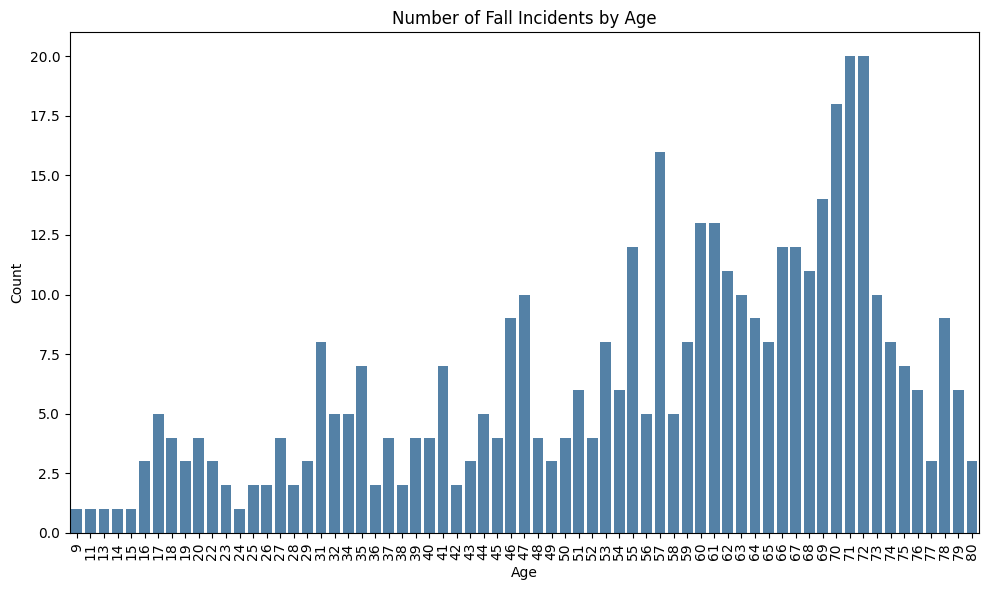

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df_falls = df_final[df_final["injury_group"] == "Fall"]

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_falls,
    x="age_estimated",
    color="steelblue"
)

plt.title("Number of Fall Incidents by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
